# 以LSTM演算法預測股價

## 載入相關套件 

In [1]:
import math
from typing import List, Tuple, cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn, optim
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

## 判斷GPU是否存在

In [2]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'mps'

## 載入資料

In [3]:
df = pd.read_csv('nlp_data/AMZN_2006-01-01_to_2018-01-01.csv')
df.head()

,Date,Open,High,Low,Close,Volume,Name
0,2006-01-03,47.47,47.85,46.25,47.58,7582127,AMZN
1,2006-01-04,47.48,47.73,46.69,47.25,7440914,AMZN
2,2006-01-05,47.16,48.20,47.11,47.65,5417258,AMZN
3,2006-01-06,47.97,48.58,47.32,47.87,6154285,AMZN
4,2006-01-09,46.55,47.10,46.40,47.08,8945056,AMZN


In [4]:
df.tail()

,Date,Open,High,Low,Close,Volume,Name
3014,2017-12-22,1172.08,1174.62,1167.83,1168.36,1585054,AMZN
3015,2017-12-26,1168.36,1178.32,1160.55,1176.76,2005187,AMZN
3016,2017-12-27,1179.91,1187.29,1175.61,1182.26,1867208,AMZN
3017,2017-12-28,1189.00,1190.10,1184.38,1186.10,1841676,AMZN
3018,2017-12-29,1182.35,1184.00,1167.50,1169.47,2688391,AMZN


## 繪圖

(array([-500.,    0.,  500., 1000., 1500., 2000., 2500., 3000., 3500.]),
 [Text(-500.0, 0, '2016-01-07'),
  Text(0.0, 0, '2006-01-03'),
  Text(500.0, 0, '2007-12-28'),
  Text(1000.0, 0, '2009-12-22'),
  Text(1500.0, 0, '2011-12-16'),
  Text(2000.0, 0, '2013-12-13'),
  Text(2500.0, 0, '2015-12-09'),
  Text(3000.0, 0, '2017-12-04'),
  Text(3500.0, 0, '')])

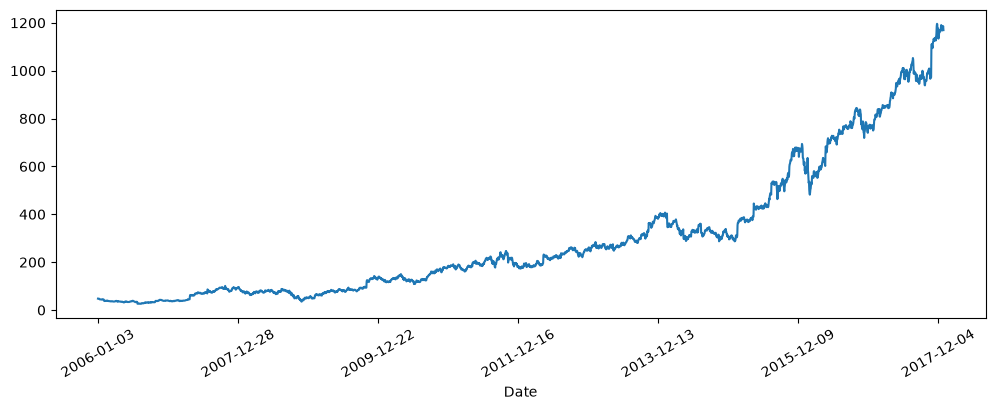

In [5]:
df2 = df.set_index('Date')
df2.Close.plot(legend=False, figsize=(12, 4))
plt.xticks(rotation=30)

In [6]:
len(df2)

3019

In [7]:
look_back = 1  # 以前N期資料為 X，當期資料為 Y


# 函數：以前N期資料為 X，當前期資料為 Y
def create_dataset(data: np.ndarray, look_back: int) -> Tuple[torch.Tensor, torch.Tensor]:
    x: List[np.ndarray] = []
    y: List[np.ndarray] = []
    for i in range(len(data) - look_back - 1):
        _x = data[i : (i + look_back)]
        _y = data[i + look_back]
        x.append(_x)
        y.append(_y)

    return torch.Tensor(np.array(x)).to(device), torch.Tensor(np.array(y)).to(device)


dataset = df2[['Close']].values.astype('float32')

# X 常態化
scaler = MinMaxScaler()
dataset = scaler.fit_transform(dataset)

# 資料分割
train_size = int(len(dataset) * 0.67)
test_size = len(dataset) - train_size
train_data, test_data = dataset[0:train_size, :], dataset[train_size : len(dataset), :]

trainX, trainY = create_dataset(train_data, look_back)
testX, testY = create_dataset(test_data, look_back)
dataset.shape, trainY.shape

((3019, 1), torch.Size([2020, 1]))

In [8]:
dataset[-1]

array([0.97746545], dtype=float32)

In [9]:
trainX.shape, trainY.shape, testX.shape, testY.shape

(torch.Size([2020, 1, 1]),
 torch.Size([2020, 1]),
 torch.Size([995, 1, 1]),
 torch.Size([995, 1]))

In [10]:
torch.cat((trainX.reshape(trainX.shape[0], trainX.shape[1]), trainY), dim=1)

tensor([[0.0184, 0.0181],
        [0.0181, 0.0184],
        [0.0184, 0.0186],
        ...,
        [0.3205, 0.3177],
        [0.3177, 0.3120],
        [0.3120, 0.3176]], device='mps:0')

## 建立模型

In [ ]:
class TimeSeriesModel(nn.Module):
    def __init__(self, hidden_size: int = 4, num_layers: int = 1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.LSTM(1, hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        self.init_weights()

    def init_weights(self):
        initrange = 0.5
        self.fc.weight.data.uniform_(-initrange, initrange)
        self.fc.bias.data.zero_()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # print(x.shape)
        # rnn_out, h_out = self.rnn(x)
        h_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=device)
        c_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=device)
        out, (h_out, _) = self.rnn(x, (h_0, c_0))
        # print(h_out.shape)

        # 取最後一層的 h，並轉成二維
        #         h_out = h_out[-1].view(-1, self.hidden_size)
        #         return self.fc(h_out)
        # 取最後一個輸出，並轉成二維
        flatten_output = cast(torch.Tensor, out)[:, -1].view(-1, self.hidden_size)
        return self.fc(flatten_output)


model = TimeSeriesModel(hidden_size=4, num_layers=1).to(device)

## 模型訓練

In [ ]:
num_epochs = 2000
learning_rate = 0.01


def train(trainX: torch.Tensor, trainY: torch.Tensor):
    criterion = nn.MSELoss()  # MSE
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        outputs: torch.Tensor = model(trainX)
        if epoch <= 0:
            print(outputs.shape)
        loss: torch.Tensor = criterion(outputs, trainY)
        loss.backward()
        optimizer.step()
        if epoch % 100 == 0:
            print(f"Epoch: {epoch}, loss: {loss.item():.5f}")


train(trainX, trainY)

torch.Size([2020, 1])
Epoch: 0, loss: 0.00780
Epoch: 100, loss: 0.00002
Epoch: 200, loss: 0.00001
Epoch: 300, loss: 0.00001
Epoch: 400, loss: 0.00001
Epoch: 500, loss: 0.00001
Epoch: 600, loss: 0.00001
Epoch: 700, loss: 0.00001
Epoch: 800, loss: 0.00001
Epoch: 900, loss: 0.00001
Epoch: 1000, loss: 0.00001
Epoch: 1100, loss: 0.00001
Epoch: 1200, loss: 0.00001
Epoch: 1300, loss: 0.00001
Epoch: 1400, loss: 0.00001
Epoch: 1500, loss: 0.00001
Epoch: 1600, loss: 0.00001
Epoch: 1700, loss: 0.00001
Epoch: 1800, loss: 0.00001
Epoch: 1900, loss: 0.00001


## 模型評估

In [ ]:
model.eval()
trainPredict = cast(torch.Tensor, model(trainX)).detach().cpu().numpy()
testPredict = cast(torch.Tensor, model(testX)).detach().cpu().numpy()
trainPredict.shape

(2020, 1)

In [14]:
trainY.shape, trainPredict.shape

(torch.Size([2020, 1]), (2020, 1))

In [15]:
# 還原常態化的訓練及測試資料
trainPredict = scaler.inverse_transform(trainPredict)
trainY_actual = scaler.inverse_transform(trainY.detach().cpu().numpy().reshape(-1, 1))
testPredict = scaler.inverse_transform(testPredict)
testY_actual = scaler.inverse_transform(testY.detach().cpu().numpy().reshape(-1, 1))
print(trainY_actual.shape, trainPredict.shape)

# 計算 RMSE
trainScore = math.sqrt(mean_squared_error(trainY_actual, trainPredict.reshape(-1)))
print(f'Train RMSE: {trainScore:.2f}')
testScore = math.sqrt(mean_squared_error(testY_actual, testPredict.reshape(-1)))
print(f'Test RMSE:  {testScore:.2f}')

(2020, 1) (2020, 1)
Train RMSE: 3.49
Test RMSE:  72.61


## 繪製實際資料和預測資料的圖表

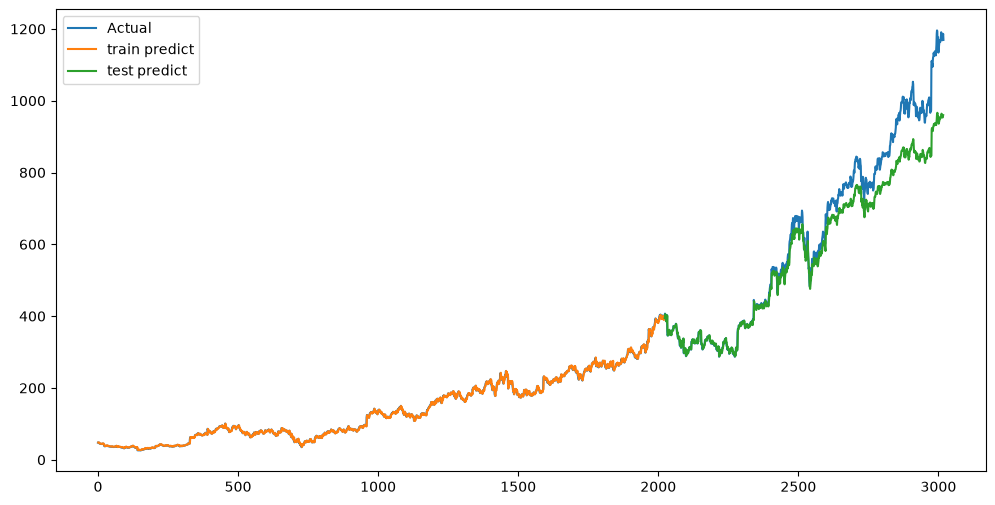

In [16]:
# 訓練資料的 X/Y
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[1 : len(trainPredict) + look_back, :] = trainPredict

# 測試資料 X/Y
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[-testPredict.shape[0] - 1 : -1, :] = testPredict

# 繪圖
plt.figure(figsize=(12, 6))
plt.plot(scaler.inverse_transform(dataset), label='Actual')
plt.plot(trainPredictPlot, label='train predict')
plt.plot(testPredictPlot, label='test predict')
plt.legend()
plt.show()

## 改變Loopback=3：X由前1期改為前3期 

In [17]:
# 以前期資料為 X，當前期資料為 Y
look_back = 3
trainX, trainY = create_dataset(train_data, look_back)
testX, testY = create_dataset(test_data, look_back)

model = TimeSeriesModel(hidden_size=4, num_layers=1).to(device)
train(trainX, trainY)

torch.Size([2018, 1])
Epoch: 0, loss: 0.00838
Epoch: 100, loss: 0.00002
Epoch: 200, loss: 0.00001
Epoch: 300, loss: 0.00001
Epoch: 400, loss: 0.00001
Epoch: 500, loss: 0.00001
Epoch: 600, loss: 0.00001
Epoch: 700, loss: 0.00001
Epoch: 800, loss: 0.00001
Epoch: 900, loss: 0.00001
Epoch: 1000, loss: 0.00001
Epoch: 1100, loss: 0.00001
Epoch: 1200, loss: 0.00001
Epoch: 1300, loss: 0.00001
Epoch: 1400, loss: 0.00001
Epoch: 1500, loss: 0.00001
Epoch: 1600, loss: 0.00001
Epoch: 1700, loss: 0.00001
Epoch: 1800, loss: 0.00001
Epoch: 1900, loss: 0.00001


In [ ]:
model.eval()
trainPredict = cast(torch.Tensor, model(trainX)).detach().cpu().numpy()
testPredict = cast(torch.Tensor, model(testX)).detach().cpu().numpy()

# 還原常態化的訓練及測試資料
trainPredict = scaler.inverse_transform(trainPredict)
trainY_actual = scaler.inverse_transform(trainY.detach().cpu().numpy().reshape(-1, 1))
testPredict = scaler.inverse_transform(testPredict)
testY_actual = scaler.inverse_transform(testY.detach().cpu().numpy().reshape(-1, 1))
print(trainY_actual.shape, trainPredict.shape)

# 計算 RMSE
trainScore = math.sqrt(mean_squared_error(trainY_actual, trainPredict.reshape(-1)))
print(f'Train RMSE: {trainScore:.2f}')
testScore = math.sqrt(mean_squared_error(testY_actual, testPredict.reshape(-1)))
print(f'Test RMSE:  {testScore:.2f}')

(2018, 1) (2018, 1)
Train RMSE: 3.76
Test RMSE:  68.21


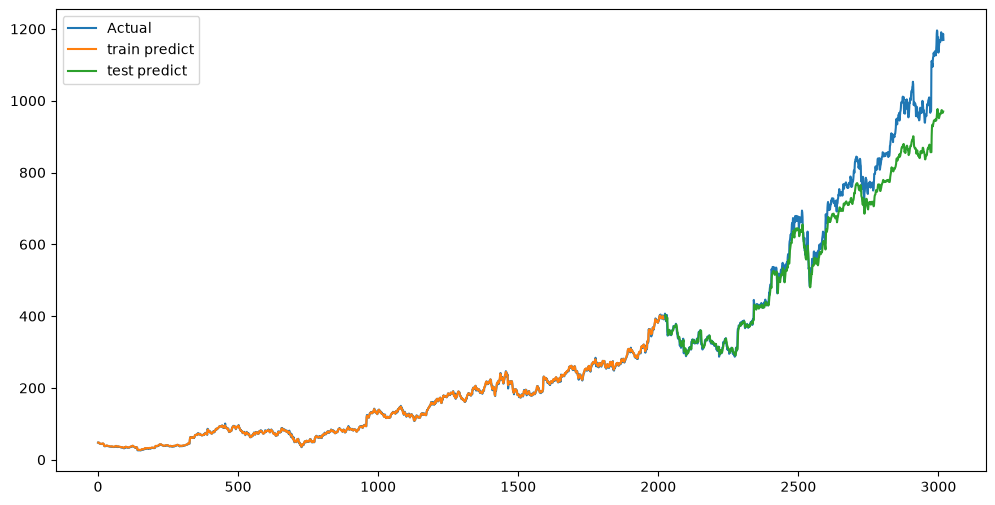

In [19]:
# 訓練資料的 X/Y
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[1 : trainPredict.shape[0] + 1 :, :] = trainPredict

# 測試資料 X/Y
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[-testPredict.shape[0] - 1 : -1, :] = testPredict

# 繪圖
plt.figure(figsize=(12, 6))
plt.plot(scaler.inverse_transform(dataset), label='Actual')
plt.plot(trainPredictPlot, label='train predict')
plt.plot(testPredictPlot, label='test predict')
plt.legend()
plt.show()

## Stacked LSTM

In [20]:
# 以前期資料為 X，當前期資料為 Y
look_back = 3
trainX, trainY = create_dataset(train_data, look_back)
testX, testY = create_dataset(test_data, look_back)

model = TimeSeriesModel(hidden_size=4, num_layers=3).to(device)
train(trainX, trainY)

torch.Size([2018, 1])
Epoch: 0, loss: 0.08436
Epoch: 100, loss: 0.00591
Epoch: 200, loss: 0.00084
Epoch: 300, loss: 0.00009
Epoch: 400, loss: 0.00003
Epoch: 500, loss: 0.00002
Epoch: 600, loss: 0.00002
Epoch: 700, loss: 0.00002
Epoch: 800, loss: 0.00003
Epoch: 900, loss: 0.00002
Epoch: 1000, loss: 0.00003
Epoch: 1100, loss: 0.00002
Epoch: 1200, loss: 0.00002
Epoch: 1300, loss: 0.00002
Epoch: 1400, loss: 0.00002
Epoch: 1500, loss: 0.00002
Epoch: 1600, loss: 0.00001
Epoch: 1700, loss: 0.00001
Epoch: 1800, loss: 0.00005
Epoch: 1900, loss: 0.00001


In [ ]:
model.eval()
trainPredict = cast(torch.Tensor, model(trainX)).detach().cpu().numpy()
testPredict = cast(torch.Tensor, model(testX)).detach().cpu().numpy()

# 還原常態化的訓練及測試資料
trainPredict = scaler.inverse_transform(trainPredict)
trainY_actual = scaler.inverse_transform(trainY.detach().cpu().numpy().reshape(-1, 1))
testPredict = scaler.inverse_transform(testPredict)
testY_actual = scaler.inverse_transform(testY.detach().cpu().numpy().reshape(-1, 1))
print(trainY_actual.shape, trainPredict.shape)

# 計算 RMSE
trainScore = math.sqrt(mean_squared_error(trainY_actual, trainPredict.reshape(-1)))
print(f'Train RMSE: {trainScore:.2f}')
testScore = math.sqrt(mean_squared_error(testY_actual, testPredict.reshape(-1)))
print(f'Test RMSE:  {testScore:.2f}')

(2018, 1) (2018, 1)
Train RMSE: 4.41
Test RMSE:  219.23


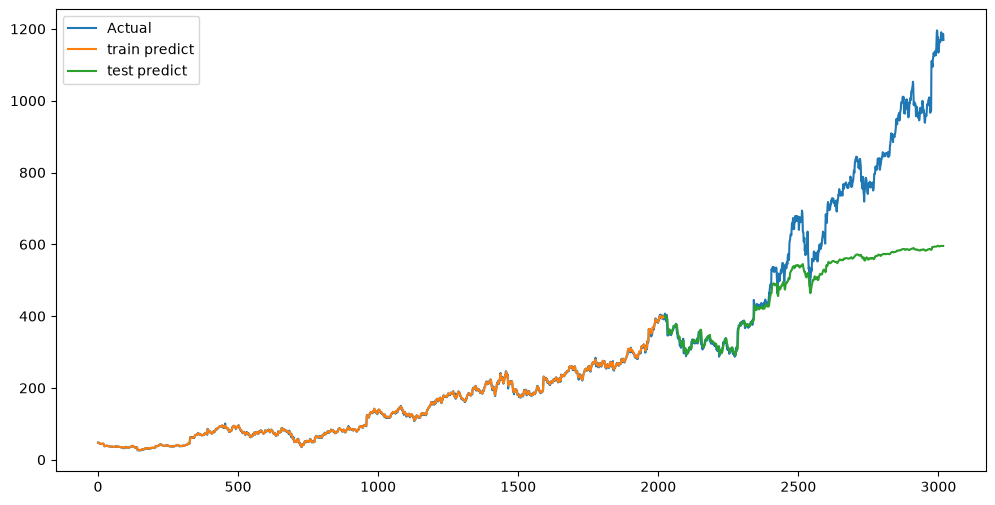

In [22]:
# 訓練資料的 X/Y
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[1 : trainPredict.shape[0] + 1 :, :] = trainPredict

# 測試資料 X/Y
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[-testPredict.shape[0] - 1 : -1, :] = testPredict

# 繪圖
plt.figure(figsize=(12, 6))
plt.plot(scaler.inverse_transform(dataset), label='Actual')
plt.plot(trainPredictPlot, label='train predict')
plt.plot(testPredictPlot, label='test predict')
plt.legend()
plt.show()

## 預測多期

In [ ]:
# 函數：以前N期資料為 X，當前期資料為 Y
def create_dataset(data: np.ndarray, look_back: int, forward_days: int):
    x, y = [], []
    for i in range(len(data) - look_back - forward_days + 1):
        _x = data[i : (i + look_back)]
        _y = data[i + look_back : (i + look_back + forward_days)]
        x.append(_x)
        y.append(_y)

    x, y = np.array(x), np.array(y)
    return torch.Tensor(x).to(device), torch.Tensor(y.reshape(y.shape[0], y.shape[1])).to(device)

## 建立資料集

In [24]:
look_back = 10  # 以前10期資料為 X
forward_days = 10  # 預測天數
trainX, trainY = create_dataset(train_data, look_back, forward_days)
testX, testY = create_dataset(test_data, look_back, forward_days)

In [25]:
train_data.shape, test_data.shape

((2022, 1), (997, 1))

In [26]:
trainX.shape, trainY.shape

(torch.Size([2003, 10, 1]), torch.Size([2003, 10]))

## 建立模型

In [ ]:
class TimeSeriesModel(nn.Module):
    def __init__(self, forward_days: int, hidden_size=4, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.LSTM(1, self.hidden_size, num_layers=self.num_layers, batch_first=True)
        self.fc = nn.Linear(self.hidden_size, forward_days)
        self.init_weights()

    def init_weights(self):
        initrange = 0.5
        self.fc.weight.data.uniform_(-initrange, initrange)
        self.fc.bias.data.zero_()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # print(x.shape)
        # rnn_out, h_out = self.rnn(x)
        h_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=device)
        c_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=device)
        out, (h_out, _) = self.rnn(x, (h_0, c_0))
        # print(h_out.shape)

        # 取最後一層的 h，並轉成二維
        # h_out = h_out[-1].view(-1, self.hidden_size)
        # return self.fc(h_out)
        # 取最後一個輸出，並轉成二維
        flatten_output = cast(torch.Tensor, out)[:, -1].view(-1, self.hidden_size)
        return self.fc(flatten_output)


model = TimeSeriesModel(forward_days, hidden_size=20, num_layers=1).to(device)

## 模型訓練

In [ ]:
def train(trainX: torch.Tensor, trainY: torch.Tensor):
    criterion = nn.MSELoss()  # MSE
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        outputs: torch.Tensor = model(trainX)
        if epoch <= 0:
            print(outputs.shape, trainY.shape)
        loss: torch.Tensor = criterion(outputs, trainY)
        loss.backward()
        optimizer.step()
        if epoch % 100 == 0:
            print(f"Epoch: {epoch}, loss: {loss.item():.5f}")


train(trainX, trainY)

torch.Size([2003, 10]) torch.Size([2003, 10])
Epoch: 0, loss: 0.04874
Epoch: 100, loss: 0.00006
Epoch: 200, loss: 0.00005
Epoch: 300, loss: 0.00005
Epoch: 400, loss: 0.00005
Epoch: 500, loss: 0.00005
Epoch: 600, loss: 0.00008
Epoch: 700, loss: 0.00005
Epoch: 800, loss: 0.00005
Epoch: 900, loss: 0.00005
Epoch: 1000, loss: 0.00014
Epoch: 1100, loss: 0.00005
Epoch: 1200, loss: 0.00005
Epoch: 1300, loss: 0.00004
Epoch: 1400, loss: 0.00004
Epoch: 1500, loss: 0.00004
Epoch: 1600, loss: 0.00004
Epoch: 1700, loss: 0.00004
Epoch: 1800, loss: 0.00004
Epoch: 1900, loss: 0.00005


In [ ]:
model.eval()
trainPredict = cast(torch.Tensor, model(trainX)).detach().cpu().numpy()
testPredict = cast(torch.Tensor, model(testX)).detach().cpu().numpy()

# 還原常態化的訓練及測試資料
trainPredict = scaler.inverse_transform(trainPredict)
trainY_actual = scaler.inverse_transform(trainY.detach().cpu().numpy().reshape(-1, 1))
testPredict = scaler.inverse_transform(testPredict)
testY_actual = scaler.inverse_transform(testY.detach().cpu().numpy().reshape(-1, 1))
print(trainY_actual.shape, trainPredict.shape)

# 計算 RMSE
trainScore = math.sqrt(mean_squared_error(trainY_actual, trainPredict.reshape(-1)))
print(f'Train RMSE: {trainScore:.2f}')
testScore = math.sqrt(mean_squared_error(testY_actual, testPredict.reshape(-1)))
print(f'Test RMSE:  {testScore:.2f}')

(20030, 1) (2003, 10)
Train RMSE: 7.70
Test RMSE:  29.59


## 繪圖

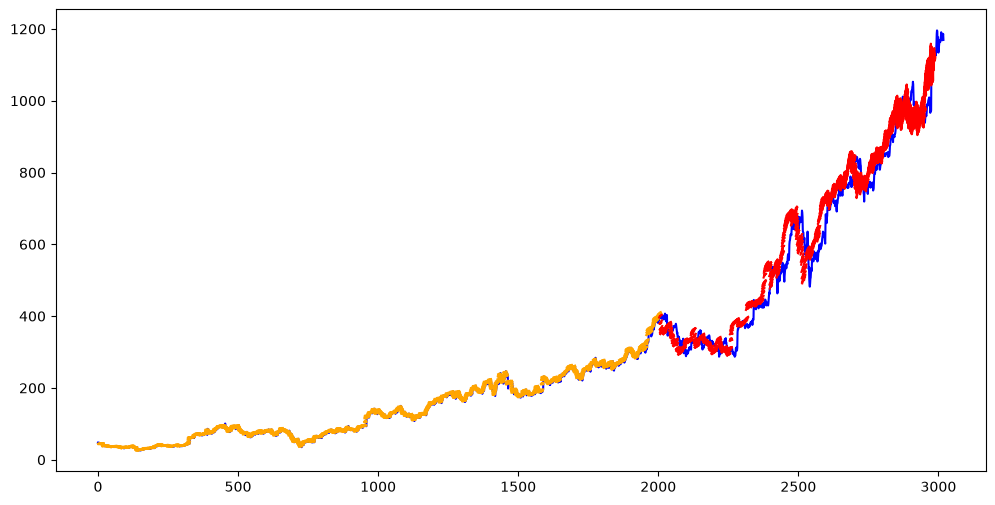

In [30]:
plt.figure(figsize=(12, 6))
# 真實資料
plt.plot(range(len(dataset)), scaler.inverse_transform(dataset), 'b', label='Actual')

# 訓練資料
for i in range(trainPredict.shape[0]):
    plt.plot(range(i, i + forward_days), trainPredict[i], 'orange')

# 測試資料
for i in range(testPredict.shape[0]):
    plt.plot(range(i + trainPredict.shape[0], i + trainPredict.shape[0] + forward_days), testPredict[i], 'r')
plt.show()

## 只繪製 20 條預測值

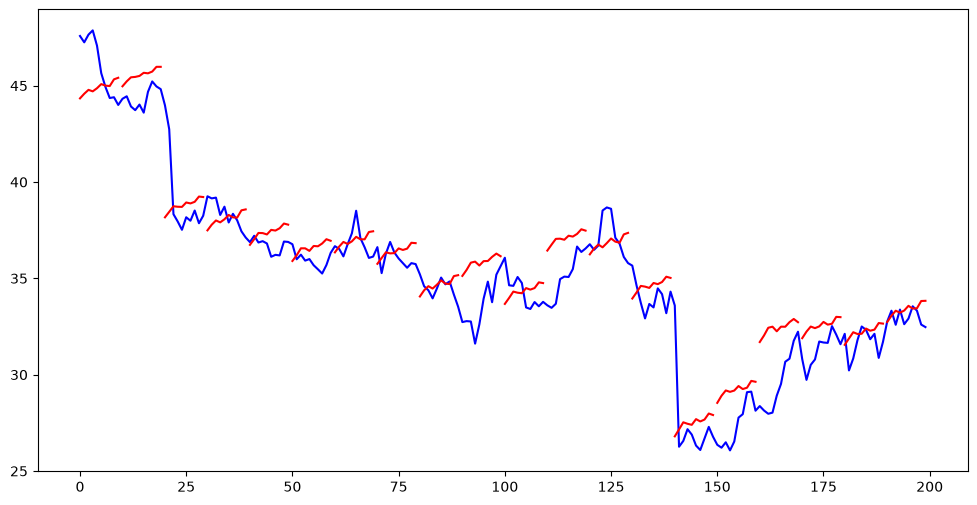

In [31]:
n = 20
plt.figure(figsize=(12, 6))
# 真實資料
plt.plot(range(forward_days * n), scaler.inverse_transform(dataset[: forward_days * n]), 'b', label='Actual')

# 訓練資料
for i in range(n):
    plt.plot(range(i * forward_days, (i + 1) * forward_days), trainPredict[i * forward_days], 'r')

plt.show()